Import Required Libraries

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

Load the Dataset

In [14]:
df = pd.read_csv("/content/Crop_Recommendation.csv")

In [15]:
print(df.head())


   Nitrogen  Phosphorus  Potassium  Temperature   Humidity  pH_Value  \
0        90          42         43    20.879744  82.002744  6.502985   
1        85          58         41    21.770462  80.319644  7.038096   
2        60          55         44    23.004459  82.320763  7.840207   
3        74          35         40    26.491096  80.158363  6.980401   
4        78          42         42    20.130175  81.604873  7.628473   

     Rainfall  Crop  
0  202.935536  Rice  
1  226.655537  Rice  
2  263.964248  Rice  
3  242.864034  Rice  
4  262.717340  Rice  


Data Exploration

In [16]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     2200 non-null   int64  
 1   Phosphorus   2200 non-null   int64  
 2   Potassium    2200 non-null   int64  
 3   Temperature  2200 non-null   float64
 4   Humidity     2200 non-null   float64
 5   pH_Value     2200 non-null   float64
 6   Rainfall     2200 non-null   float64
 7   Crop         2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None
          Nitrogen   Phosphorus    Potassium  Temperature     Humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    

Data Visualization

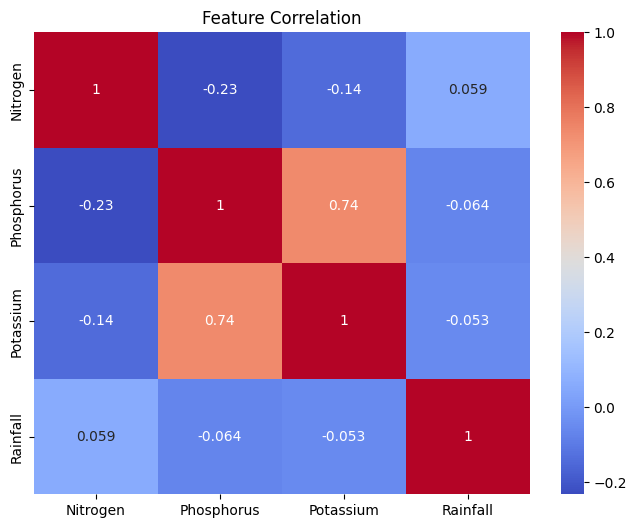

In [30]:
plt.figure(figsize=(8,6))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

Handle Missing Values

In [32]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
df[['Nitrogen','Phosphorus','Potassium','Rainfall']] = imputer.fit_transform(df[['Nitrogen','Phosphorus','Potassium','Rainfall']])

Feature and Target Selection

In [35]:
X = df[['Nitrogen','Phosphorus','Potassium','Rainfall']]
y = df['Crop']

Split Dataset into Training and Testing

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Feature Scaling

In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Train Machine Learning Models
Random Forest Model

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train_encoded)

RandomForestClassifier(random_state=42)

Compare with Linear Regression

In [42]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(solver='liblinear', random_state=42)
lr_model.fit(X_train, y_train_encoded)

LogisticRegression(random_state=42, solver='liblinear')

Model Prediction

In [43]:
y_pred = model.predict(X_test)
lr_pred = lr_model.predict(X_test)

Model Evaluation

In [48]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Model Accuracy:", accuracy_score(y_test_encoded, y_pred))

print(classification_report(y_test_encoded, y_pred))

Model Accuracy: 0.9068181818181819
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       0.90      0.95      0.93        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       0.94      1.00      0.97        17
           6       0.94      1.00      0.97        17
           7       1.00      1.00      1.00        14
           8       0.80      0.87      0.83        23
           9       0.56      0.50      0.53        20
          10       0.91      0.91      0.91        11
          11       1.00      0.95      0.98        21
          12       1.00      1.00      1.00        19
          13       0.74      0.71      0.72        24
          14       0.62      0.68      0.65        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00   

Feature Importance

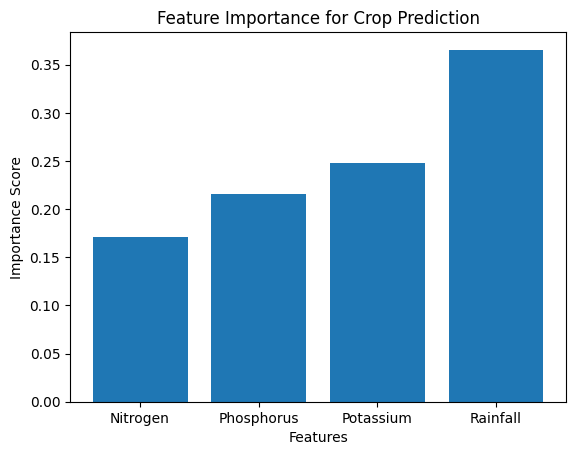

In [49]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

features = ['Nitrogen','Phosphorus','Potassium','Rainfall']

plt.bar(features, importance)

plt.title("Feature Importance for Crop Prediction")

plt.xlabel("Features")

plt.ylabel("Importance Score")

plt.show()

Visualize Predictions

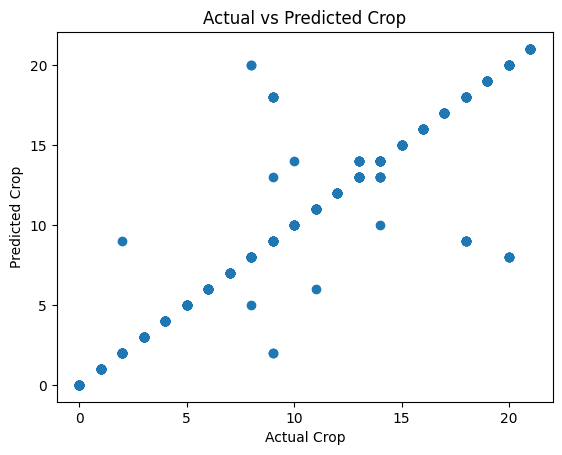

In [50]:
plt.scatter(y_test_encoded, y_pred)

plt.xlabel("Actual Crop")

plt.ylabel("Predicted Crop")

plt.title("Actual vs Predicted Crop")

plt.show()

Create Prediction Function

In [52]:
def predict_crop(N, P, K, rainfall):

    input_data = [[N, P, K, rainfall]]

    input_data = scaler.transform(input_data)

    prediction = model.predict(input_data)

    crop = le.inverse_transform(prediction)

    return crop[0]

In [56]:
import pickle

pickle.dump(model, open("crop_prediction_model.pkl","wb"))